# Nearest Earth Objects Hazard Prediction with EDA & Random Forest

## 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


## 2. Load Dataset

In [2]:

df = pd.read_csv("nearest-earth-objects(1910-2024).csv")  # replace with actual file
df.head()


,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,162117 (1998 SD15),19.14,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
1,2349507,349507 (2008 QY),18.50,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
2,2455415,455415 (2003 GA),21.45,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
3,3132126,(2002 PB),20.63,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
4,3557844,(2011 DW),22.70,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False


## 3. Dataset Overview

In [3]:

df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338199 entries, 0 to 338198
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   neo_id                  338199 non-null  int64  
 1   name                    338199 non-null  object 
 2   absolute_magnitude      338171 non-null  float64
 3   estimated_diameter_min  338171 non-null  float64
 4   estimated_diameter_max  338171 non-null  float64
 5   orbiting_body           338199 non-null  object 
 6   relative_velocity       338199 non-null  float64
 7   miss_distance           338199 non-null  float64
 8   is_hazardous            338199 non-null  bool   
dtypes: bool(1), float64(5), int64(1), object(2)
memory usage: 21.0+ MB


,neo_id,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
count,3.381990e+05,338171.000000,338171.000000,338171.000000,338199.000000,3.381990e+05
mean,1.759939e+07,22.932525,0.157812,0.352878,51060.662908,4.153535e+07
std,2.287225e+07,2.911216,0.313885,0.701869,26399.238435,2.077399e+07
min,2.000433e+06,9.250000,0.000511,0.001143,203.346433,6.745533e+03
25%,3.373980e+06,20.740000,0.025384,0.056760,30712.031471,2.494540e+07
50%,3.742127e+06,22.800000,0.073207,0.163697,47560.465474,4.332674e+07
75%,5.405374e+07,25.100000,0.189041,0.422708,66673.820614,5.933961e+07
max,5.446281e+07,33.580000,37.545248,83.953727,291781.106613,7.479865e+07


## 4. Missing Values Analysis

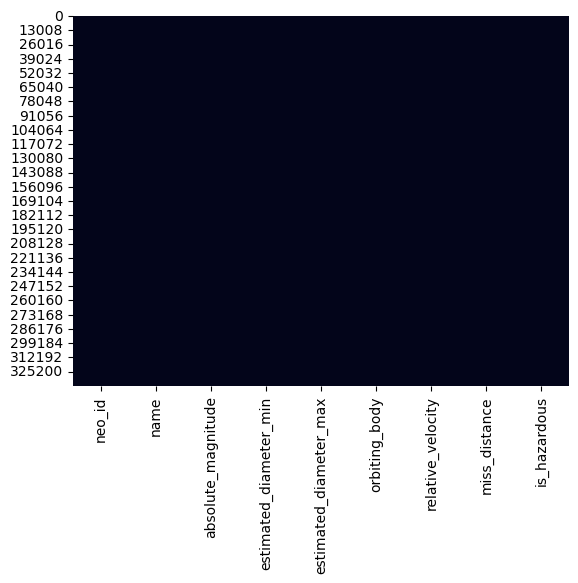

In [4]:

df.isnull().sum()
sns.heatmap(df.isnull(), cbar=False)
plt.show()


## 5. Target Distribution

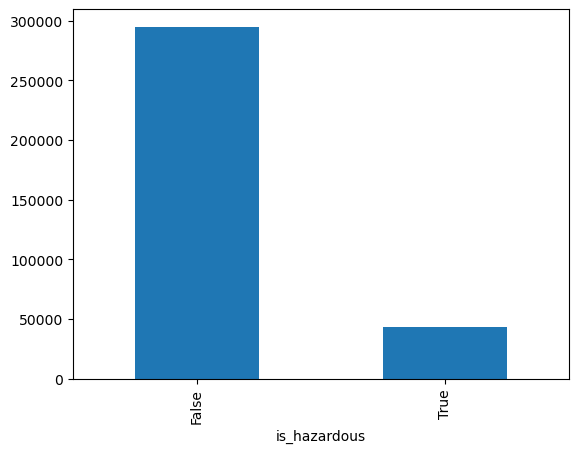

In [5]:

df['is_hazardous'].value_counts().plot(kind='bar')
plt.show()


#6. Correlation Analysis

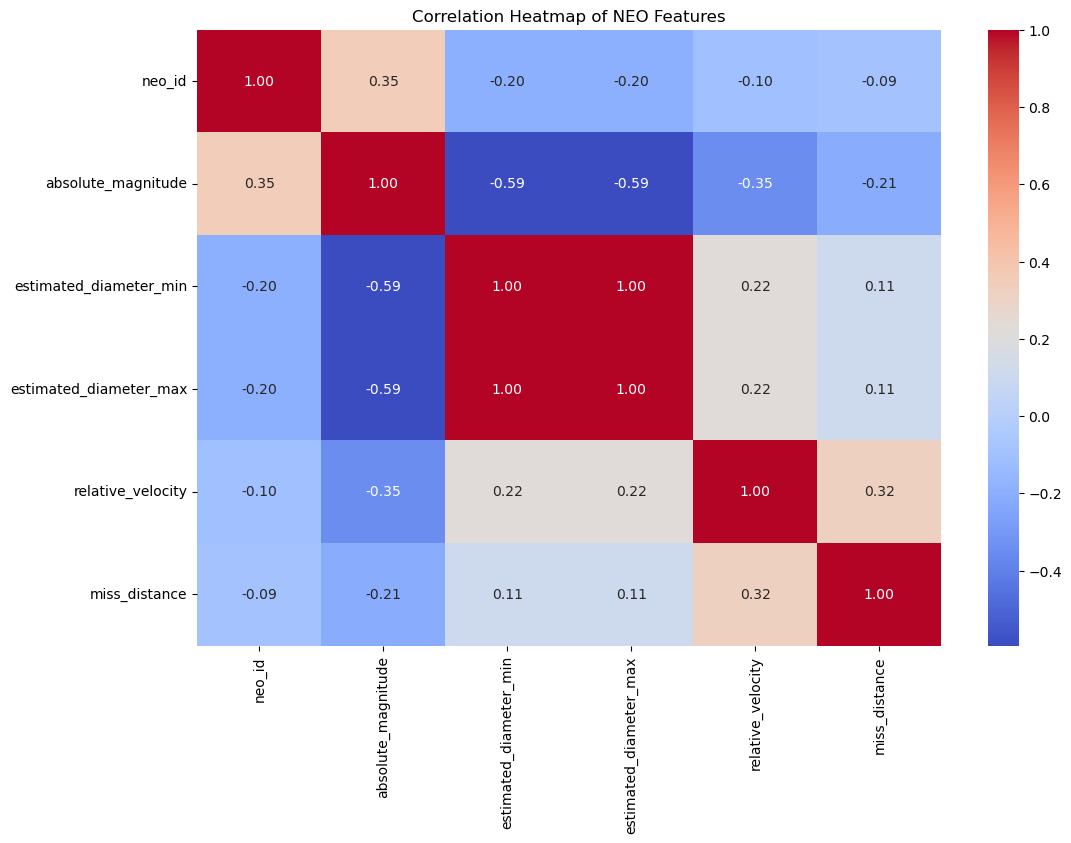

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'neo_id',
    'absolute_magnitude',
    'estimated_diameter_min',
    'estimated_diameter_max',
    'relative_velocity',
    'miss_distance'
]

plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of NEO Features")
plt.show()


This project predicts hazardous NEOs using EDA and Random Forest classification.

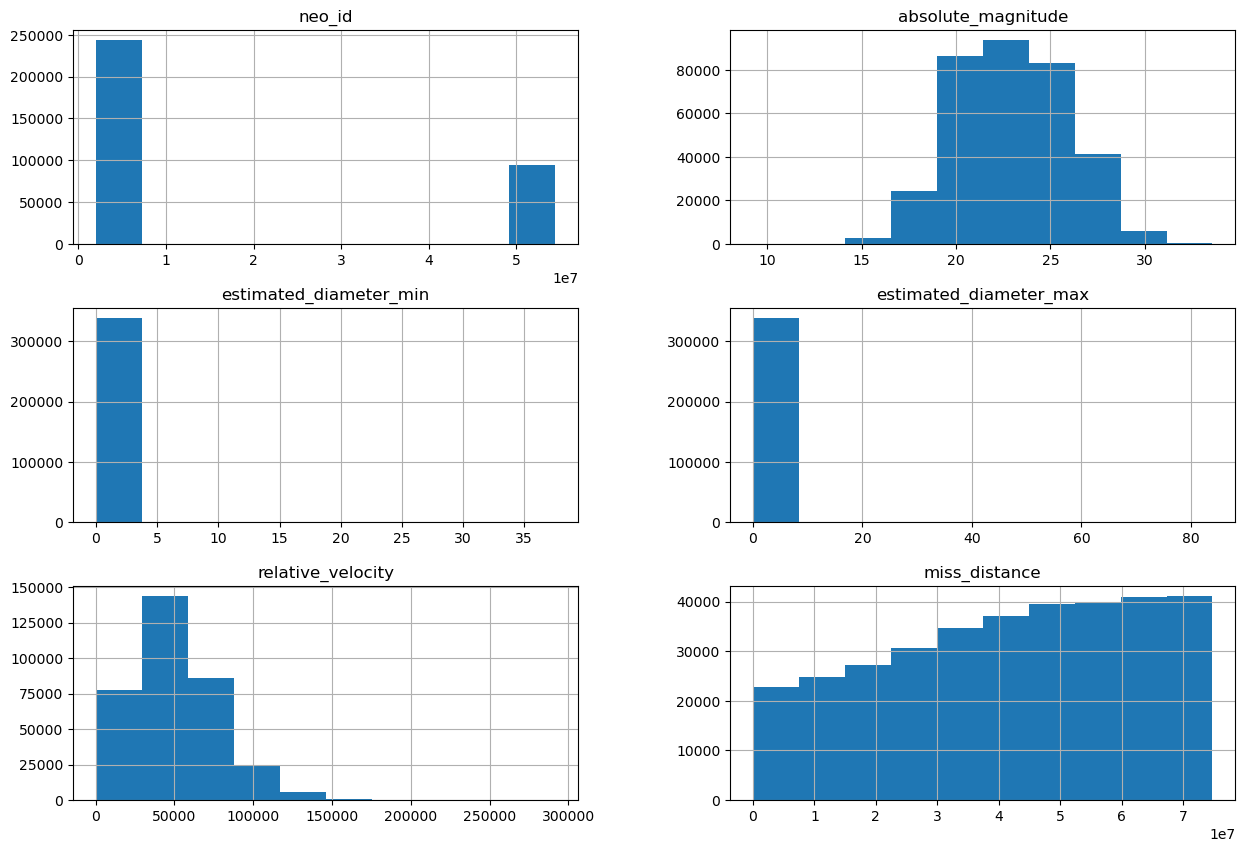

In [7]:
df[numeric_cols].hist(figsize=(15,10))
plt.show()


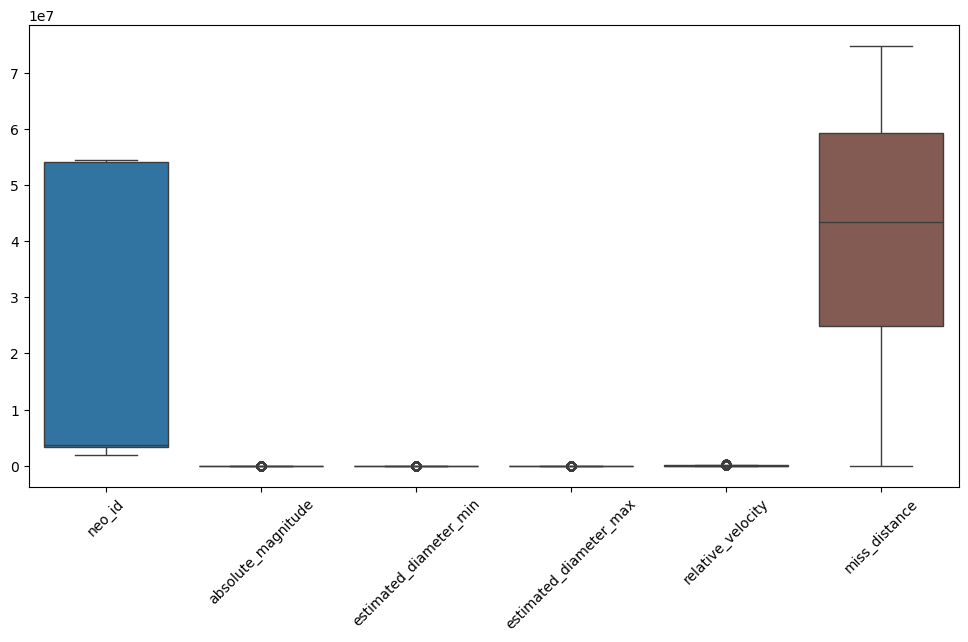

In [8]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.show()


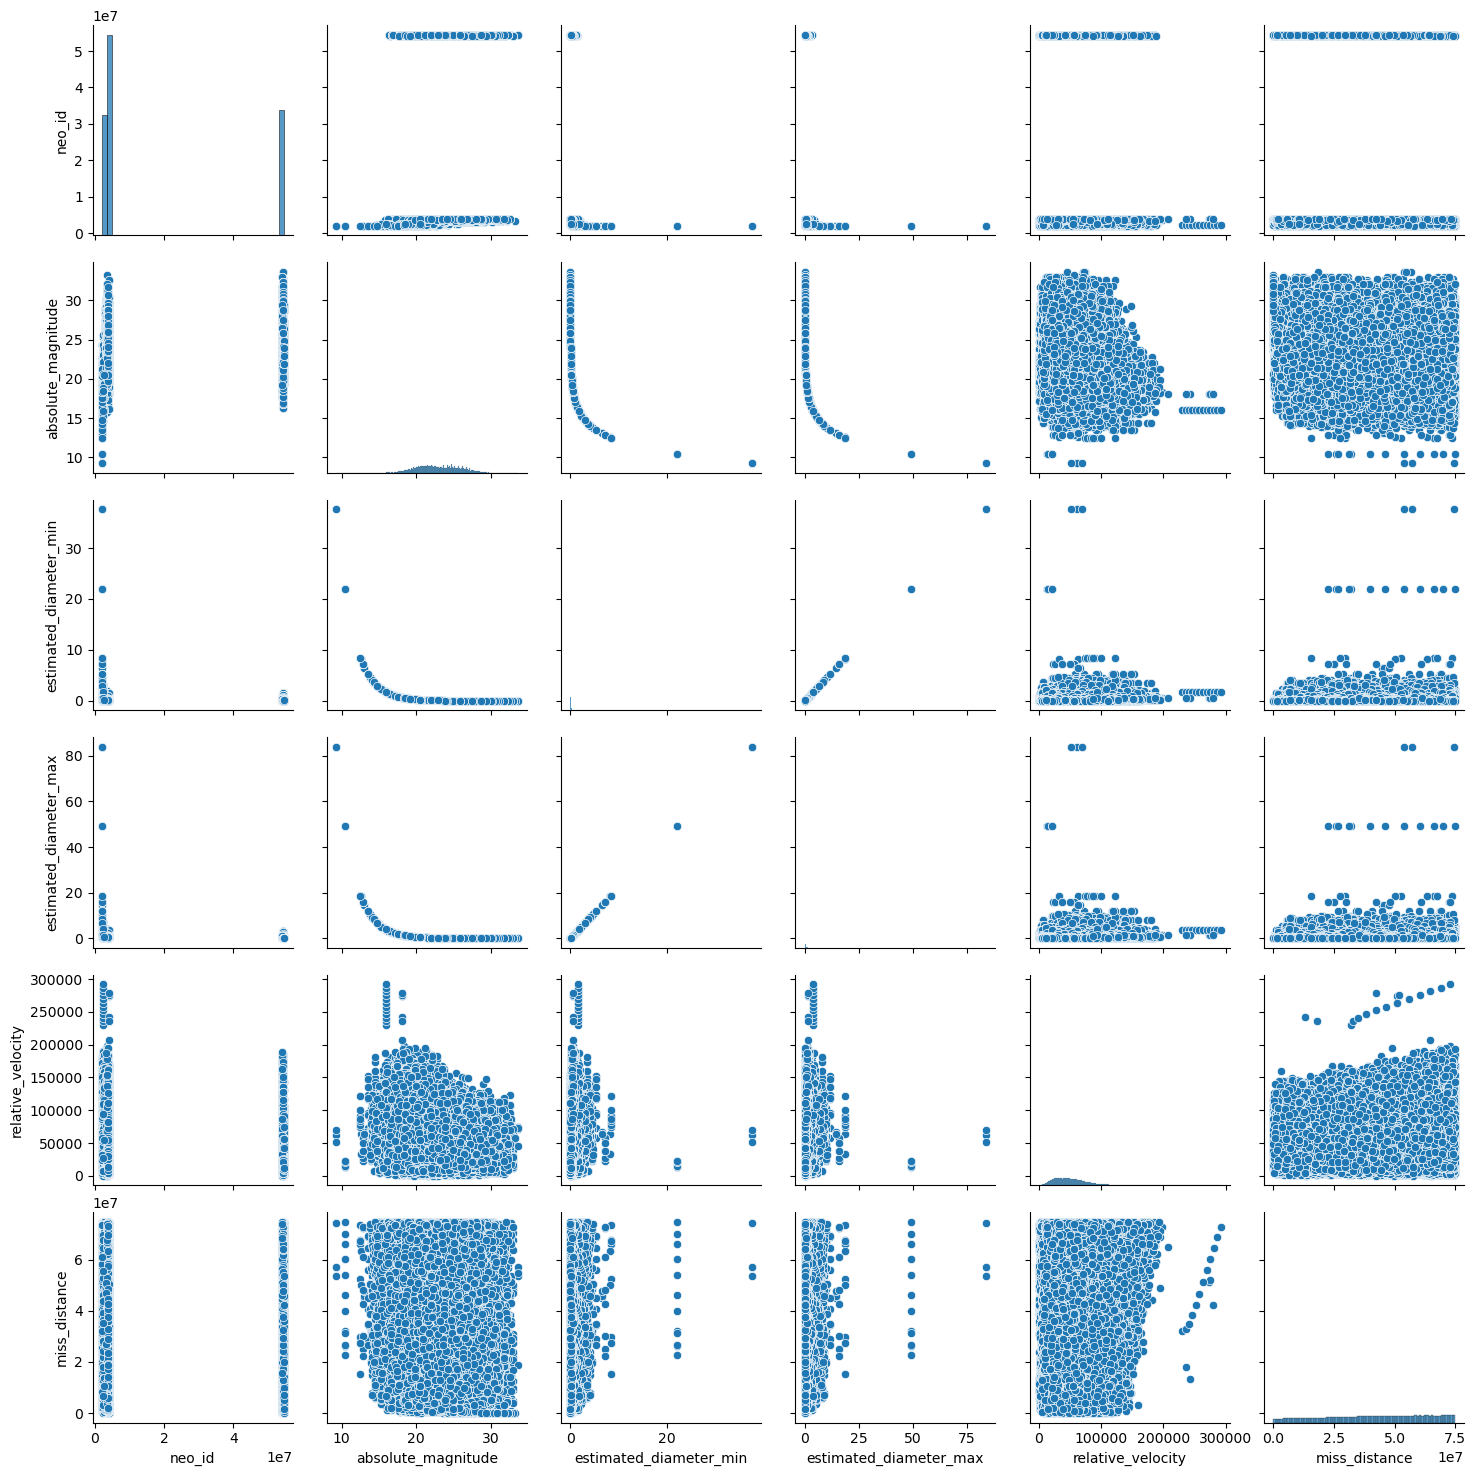

In [9]:
sns.pairplot(df[numeric_cols])
plt.show()


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[numeric_cols])


In [11]:
# Target distribution
df['is_hazardous'].value_counts()


is_hazardous
False    295037
True      43162
Name: count, dtype: int64

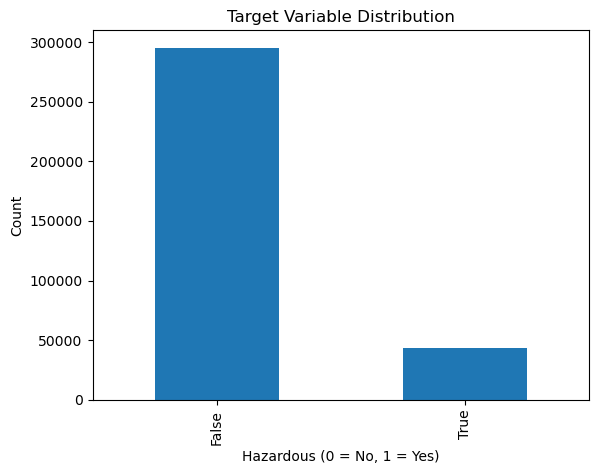

In [12]:
import matplotlib.pyplot as plt

df['is_hazardous'].value_counts().plot(kind='bar')
plt.xlabel("Hazardous (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Target Variable Distribution")
plt.show()


In [13]:
df['is_hazardous'].value_counts(normalize=True) * 100


is_hazardous
False    87.237691
True     12.762309
Name: proportion, dtype: float64

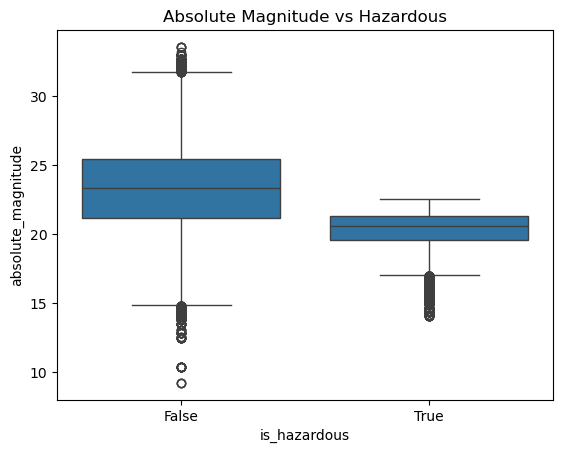

In [14]:
import seaborn as sns

sns.boxplot(x='is_hazardous', y='absolute_magnitude', data=df)
plt.title("Absolute Magnitude vs Hazardous")
plt.show()


In [15]:
df['estimated_diameter_mean'] = (
    df['estimated_diameter_min'] + df['estimated_diameter_max']
) / 2


In [16]:
def size_category(d):
    if d < 0.05:
        return 0   # Small
    elif d < 0.2:
        return 1   # Medium
    else:
        return 2   # Large

df['size_category'] = df['estimated_diameter_mean'].apply(size_category)


In [17]:
def velocity_category(v):
    if v < 20000:
        return 0   # Slow
    elif v < 40000:
        return 1   # Medium
    else:
        return 2   # Fast

df['velocity_category'] = df['relative_velocity'].apply(velocity_category)


In [18]:
df['risk_score'] = (
    df['estimated_diameter_mean'] * df['relative_velocity']
) / df['miss_distance']


In [19]:
df = df.drop(['estimated_diameter_min', 'estimated_diameter_max'], axis=1)


In [20]:
df.columns


Index(['neo_id', 'name', 'absolute_magnitude', 'orbiting_body',
       'relative_velocity', 'miss_distance', 'is_hazardous',
       'estimated_diameter_mean', 'size_category', 'velocity_category',
       'risk_score'],
      dtype='object')

In [21]:
df = df.drop(['name', 'orbiting_body'], axis=1)


In [22]:


# Convert target to int
df['is_hazardous'] = df['is_hazardous'].astype(int)

# Split features & target
X = df.drop('is_hazardous', axis=1)
y = df['is_hazardous']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.797397989355411
              precision    recall  f1-score   support

           0       1.00      0.77      0.87     59008
           1       0.38      0.98      0.55      8632

    accuracy                           0.80     67640
   macro avg       0.69      0.88      0.71     67640
weighted avg       0.92      0.80      0.83     67640



In [38]:
from xgboost import XGBClassifier
XGBClassifier(
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    max_depth=6,
    n_estimators=200,
    learning_rate=0.1
)


xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


XGBoost Accuracy: 0.9358515671200474
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     59008
           1       0.90      0.56      0.69      8632

    accuracy                           0.94     67640
   macro avg       0.92      0.78      0.83     67640
weighted avg       0.93      0.94      0.93     67640



In [40]:
df

,neo_id,absolute_magnitude,relative_velocity,miss_distance,is_hazardous,estimated_diameter_mean,size_category,velocity_category,risk_score
0,2162117,19.140,71745.401048,5.814362e+07,0,0.639061,2,2,0.000789
1,2349507,18.500,109949.757148,5.580105e+07,1,0.858109,2,2,0.001691
2,2455415,21.450,24865.506798,6.720689e+07,0,0.220568,2,1,0.000082
3,3132126,20.630,78890.076805,3.039644e+07,0,0.321768,2,2,0.000835
4,3557844,22.700,56036.519484,6.311863e+07,0,0.124035,1,2,0.000110
...,...,...,...,...,...,...,...,...,...
338194,54403809,28.580,56646.985988,6.406548e+07,0,0.008271,0,2,0.000007
338195,54415298,28.690,21130.768947,2.948883e+07,0,0.007862,0,1,0.000006
338196,54454871,21.919,11832.041031,5.346078e+07,0,0.177723,1,0,0.000039
338197,54456245,23.887,56198.382733,5.184742e+06,0,0.071803,1,2,0.000778


In [45]:
X_train.columns


Index(['neo_id', 'absolute_magnitude', 'relative_velocity', 'miss_distance',
       'estimated_diameter_mean', 'size_category', 'velocity_category',
       'risk_score'],
      dtype='object')

In [48]:
y_prob = xgb_model.predict_proba(X_test)[:,1]
y_prob

array([6.2357431e-06, 7.4296132e-02, 7.5575108e-06, ..., 6.3445814e-06,
       3.1462794e-06, 4.3339301e-06], dtype=float32)

In [49]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.linspace(0,1,200)
scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    scores.append(f1_score(y_test, y_pred))

best_threshold = thresholds[np.argmax(scores)]
print("Best Threshold:", best_threshold)


Best Threshold: 0.36683417085427134


In [50]:
import numpy as np

# Example new asteroid
new_asteroid = np.array([[ 
    9999999,       # neo_id (can be any ID)
    20.5,          # absolute_magnitude
    85000,        # relative_velocity
    4.2e7,        # miss_distance
    0.35,         # estimated_diameter_mean
    2,            # size_category
    2,            # velocity_category
    0.0012        # risk_score
]])

hazard_prob = xgb_model.predict_proba(new_asteroid)[0][1]

print("Hazard Probability:", hazard_prob)

threshold = 0.37   # NASA-style

if hazard_prob >= threshold:
    print("🚨 HAZARDOUS ASTEROID")
else:
    print("✅ SAFE ASTEROID")


Hazard Probability: 0.17790747
✅ SAFE ASTEROID


In [51]:
import joblib

joblib.dump(xgb_model, "asteroid_xgb.pkl")


['asteroid_xgb.pkl']